# 🫁 Classification des Sons Respiratoires — AST + SAM

Ce notebook reproduit le pipeline complet du projet ICBHI-AST-SAM :
1. Prétraitement des données ICBHI 2017
2. Définition du modèle (AST + SAM)
3. Entraînement (fine-tuning)
4. Évaluation et visualisation

##  1. Installation des dépendances

In [ ]:
!pip install torch torchaudio transformers librosa scikit-learn matplotlib seaborn tqdm soundfile -q

##  1.5 Monter Google Drive

Sauvegarder les données prétraitées et les poids du modèle sur Drive pour ne rien perdre.

In [ ]:
# Monter Google Drive pour sauvegarder données + modèle
from google.colab import drive
drive.mount('/content/drive')

# Dossier de travail sur Drive
DRIVE_DIR = "/content/drive/MyDrive/ICBHI_AST_SAM"
import os
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(f"{DRIVE_DIR}/checkpoints", exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import ASTModel, ASTFeatureExtractor
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import gc

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


##  Téléchargement du Dataset ICBHI 2017

Le dataset contient 920 fichiers (.wav + .txt) de sons respiratoires enregistrés par stéthoscope.

In [ ]:
# Télécharger le dataset ICBHI
# Charger le dataset depuis Drive (ou le télécharger une seule fois)
import os

"""ZIP_PATH = f"{DRIVE_DIR}/ICBHI_final_database.zip"
SPLIT_SRC = f"{DRIVE_DIR}/ICBHI_challenge_train_test.txt"

# Si le ZIP n'est pas encore sur Drive → le télécharger et sauvegarder sur Drive
if not os.path.exists(ZIP_PATH):
    print("⬇ Téléchargement du dataset (une seule fois)...")
    !wget --no-check-certificate https://bhichallenge.med.auth.gr/sites/default/files/ICBHI_final_database/ICBHI_final_database.zip -O "{ZIP_PATH}"
    !wget --no-check-certificate https://bhichallenge.med.auth.gr/sites/default/files/ICBHI_final_database/ICBHI_challenge_train_test.txt -O "{SPLIT_SRC}"
# Dézipper dans le stockage local de Colab
!unzip -q "{ZIP_PATH}" -d ./data/
!cp "{SPLIT_SRC}" ./data/ICBHI_Challenge_train_test.txt"""
DATA_DIR = "./data/ICBHI_final_database"
SPLIT_FILE = "./data/ICBHI_Challenge_train_test.txt"



##  4. Prétraitement

### 4.1 Constantes et fonctions utilitaires
- **16 kHz** : fréquence d'échantillonnage attendue par AST
- **8 secondes** : durée fixe pour chaque cycle
- **Cyclic Padding** : on répète le signal au lieu d'ajouter des zéros

In [ ]:
TARGET_SR = 16000       # Fréquence d'échantillonnage
TARGET_DURATION = 8     # Durée cible en secondes
TARGET_SAMPLES = TARGET_SR * TARGET_DURATION  # 128000 échantillons

# Mapping des stéthoscopes utilisés
DEVICE_MAP = {'AKGC417L': 0, 'LittC2SE': 1, 'Litt3200': 2, 'Meditron': 3}

def get_device_id(filename):
    """Extrait l'ID du stéthoscope depuis le nom du fichier."""
    dev_name = filename.split('_')[-1]
    return DEVICE_MAP.get(dev_name, -1)

def cyclic_padding(wav, target_len):
    """Répète le signal en boucle pour atteindre target_len échantillons."""
    if len(wav) >= target_len:
        return wav[:target_len]
    repeat_count = (target_len // len(wav)) + 1
    return np.tile(wav, repeat_count)[:target_len]


### 4.2 Traitement des données

Pour chaque enregistrement :
1. Charger le .wav à 16kHz
2. Lire les annotations .txt (cycles respiratoires)
3. Découper chaque cycle + cyclic padding à 8s
4. Assigner le label (0:Normal, 1:Crackle, 2:Wheeze, 3:Both)

In [4]:
DRIVE_DIR = "/content/drive/MyDrive/ICBHI_AST_SAM"
NPZ_PATH  = f"{DRIVE_DIR}/icbhi_preprocessed.npz"

In [ ]:
def process_data():
    split_df = pd.read_csv(SPLIT_FILE, sep='\t', names=['filename', 'set_type'])
    X_train, y_train, device_train = [], [], []
    X_test, y_test, device_test = [], [], []

    for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
        fname, set_type = row['filename'], row['set_type']
        wav_path = os.path.join(DATA_DIR, fname + '.wav')
        txt_path = os.path.join(DATA_DIR, fname + '.txt')

        if not os.path.exists(wav_path) or not os.path.exists(txt_path):
            continue

        audio, _ = librosa.load(wav_path, sr=TARGET_SR)
        dev_id = get_device_id(fname)
        anns = pd.read_csv(txt_path, sep='\t', names=['start', 'end', 'crackle', 'wheeze'])

        for _, ann in anns.iterrows():
            start = int(ann['start'] * TARGET_SR)
            end = int(ann['end'] * TARGET_SR)
            chunk = audio[start:end]

            if len(chunk) < 100:
                continue

            processed_wav = cyclic_padding(chunk, TARGET_SAMPLES)

            c, w = ann['crackle'], ann['wheeze']
            if c == 0 and w == 0: label = 0
            elif c == 1 and w == 0: label = 1
            elif c == 0 and w == 1: label = 2
            else: label = 3

            if set_type == 'train':
                X_train.append(processed_wav)
                y_train.append(label)
                device_train.append(dev_id)
            else:
                X_test.append(processed_wav)
                y_test.append(label)
                device_test.append(dev_id)

    return (np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.int64),
            np.array(device_train, dtype=np.int64), np.array(X_test, dtype=np.float32),
            np.array(y_test, dtype=np.int64), np.array(device_test, dtype=np.int64))
NPZ_PATH = f"{DRIVE_DIR}/icbhi_preprocessed.npz"

if os.path.exists(NPZ_PATH):
    data = np.load(NPZ_PATH)
    X_train = data['X_train']
    y_train = data['y_train']
    d_train = data['d_train']
    X_test = data['X_test']
    y_test = data['y_test']
    d_test = data['d_test']
    print(f"Train: {X_train.shape}, Test: {X_test.shape}")
else:
    X_train, y_train, d_train, X_test, y_test, d_test = process_data()
    np.savez(NPZ_PATH,
             X_train=X_train, y_train=y_train, d_train=d_train,
             X_test=X_test, y_test=y_test, d_test=d_test)

print(f"Distribution: {np.bincount(y_train)}")

Train: (4131, 128000), Test: (2756, 128000)
Distribution: [2057 1210  501  363]


In [5]:
import numpy as np
NPZ_PATH = f"{DRIVE_DIR}/icbhi_preprocessed.npz"
data = np.load(NPZ_PATH)
y_train = data['y_train']
y_test  = data['y_test']
X_train = data['X_train']
X_test  = data['X_test']

y= np.concatenate([y_train, y_test])
x=np.concatenate([X_train, X_test])
counts = np.bincount(y)
print("les labels",y)
print(counts)

les labels [2 0 2 ... 0 0 0]
[3636 1859  886  506]


In [6]:
d_train = data['d_train']
d_test = data['d_test']

##  5. Définition du Modèle

### 5.1 Optimiseur SAM (Sharpness-Aware Minimization)
SAM cherche des minima plats dans la loss landscape pour une meilleure généralisation.
Il fait 2 passes par batch : perturber les poids (pire cas) puis optimiser.

In [7]:
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["old_p"] = p.data.clone()
                e_w = (torch.pow(p, 2) if group["adaptive"] else 1.0) * p.grad * scale.to(p)
                p.add_(e_w)
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.data = self.state[p]["old_p"]
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norm = torch.norm(torch.stack([
            ((torch.abs(p) if group["adaptive"] else 1.0) * p.grad).norm(p=2).to(shared_device)
            for group in self.param_groups for p in group["params"]
            if p.grad is not None
        ]), p=2)
        return norm



### 5.2 Dataset PyTorch
Convertit les wav bruts en spectrogrammes via ASTFeatureExtractor.
Applique une augmentation légère (gain + bruit) pendant l'entraînement.

In [8]:
class ASTDataset(Dataset):
    def __init__(self, X, y, device_ids, processor, train=True):
        self.X, self.y, self.device_ids = X, y, device_ids
        self.processor, self.train = processor, train

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        wav = self.X[idx]
        if self.train:
            if np.random.random() < 0.5:
                wav = wav * np.random.uniform(0.9, 1.1)
            if np.random.random() < 0.5:
                wav = wav + np.random.normal(0, 0.0001, wav.shape)
        inputs = self.processor(wav, sampling_rate=16000, return_tensors="pt")
        input_values = inputs.input_values.squeeze(0)
        return input_values, torch.tensor(self.y[idx], dtype=torch.long), self.device_ids[idx]



### 5.3 Modèle CustomAST
AST pré-entraîné sur AudioSet + nouvelle tête de classification à 4 classes.
Mean Pooling sur tous les patches du spectrogramme.

In [9]:
class CustomAST(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.ast = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        outputs = self.ast(x)
        embeddings = outputs.last_hidden_state.mean(dim=1)
        logits = self.classifier(embeddings)
        return logits



##  6. Entraînement

- **SAM + AdamW** : optimiseur avec 2 passes par batch
- **WeightedRandomSampler** : compense le déséquilibre des classes
- **Label Smoothing** : empêche le modèle d'être trop confiant
- Le meilleur modèle (ICBHI Score) est sauvegardé automatiquement

In [13]:
# Hyperparamètres
EPOCHS         = 20
BATCH_SIZE     = 8
LR             = 1e-5
CHECKPOINT_DIR = f"{DRIVE_DIR}/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Processor et DataLoaders
processor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

counts  = np.bincount(y_train)
weights = [1.0/counts[y] for y in y_train]
sampler = WeightedRandomSampler(weights, len(y_train))

train_loader = DataLoader(ASTDataset(X_train, y_train, d_train, processor, train=True),
                          batch_size=BATCH_SIZE, sampler=sampler)
test_loader  = DataLoader(ASTDataset(X_test, y_test, d_test, processor, train=False),
                          batch_size=BATCH_SIZE, shuffle=False)

# Modèle, Optimiseur, Loss
model     = CustomAST(num_classes=4).to(DEVICE)
optimizer = SAM(model.parameters(), torch.optim.AdamW, lr=LR, rho=0.05, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


RESUME_PATH = os.path.join(CHECKPOINT_DIR, "resume_checkpoint.pth")
BEST_PATH   = os.path.join(CHECKPOINT_DIR, "best_model.pth")

start_epoch = 0
best_score  = 0.0

if os.path.exists(RESUME_PATH):
    ckpt = torch.load(RESUME_PATH, map_location=DEVICE,weights_only=False)
    model.load_state_dict(ckpt["model"])
    start_epoch = 15
    best_score  = ckpt["best_score"]
    print(f"Reprise depuis epoch {start_epoch + 1}/{EPOCHS} | Meilleur score: {best_score:.4f}")
elif os.path.exists(BEST_PATH):

    model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE,weights_only=False))
    start_epoch = 15
    best_score  = 0.6708
    print(f"best_model.pth charge | Reprise depuis epoch {start_epoch + 1}/{EPOCHS} | Score: {best_score:.4f}")
else:
    print(f"Pret (nouveau départ) : {sum(p.numel() for p in model.parameters())/1e6:.1f}M paramètres")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Reprise depuis epoch 16/20 | Meilleur score: 0.6708


In [14]:


for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for inputs, labels, _ in progress:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # SAM Step 1 : perturbation (pire cas)
        logits = model(inputs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        # SAM Step 2 : vraie mise à jour
        criterion(model(inputs), labels).backward()
        optimizer.second_step(zero_grad=True)

        running_loss += loss.item()
        progress.set_postfix({'Loss': loss.item()})


    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels, _ in test_loader:
            preds = torch.argmax(model(inputs.to(DEVICE)), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    se = np.sum(cm[1:, 1:]) / np.sum(cm[1:, :]) if np.sum(cm[1:, :]) > 0 else 0
    sp = cm[0, 0] / np.sum(cm[0, :]) if np.sum(cm[0, :]) > 0 else 0
    score = (se + sp) / 2

    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f} | "
          f"Se={se:.4f} | Sp={sp:.4f} | Score={score:.4f}")

    # Sauvegarder le meilleur modèle si score amélioré
    if score > best_score:
        best_score = score
        torch.save(model.state_dict(), BEST_PATH)
        print(f"    --> Meilleur modèle sauvegardé ({best_score:.4f})")

    # Sauvegarder le checkpoint de reprise à chaque époque
    torch.save({
        "epoch":      epoch,
        "model":      model.state_dict(),
        "best_score": best_score,
    }, RESUME_PATH)

print(f"\nMeilleur Score: {best_score:.4f}")


Epoch 16: Loss=0.3869 | Se=0.5692 | Sp=0.7631 | Score=0.6662


Epoch 17: Loss=0.3801 | Se=0.6508 | Sp=0.6523 | Score=0.6516


Epoch 18: Loss=0.3783 | Se=0.6602 | Sp=0.6593 | Score=0.6597


Epoch 19: Loss=0.3746 | Se=0.6143 | Sp=0.6954 | Score=0.6548


Epoch 20: Loss=0.3666 | Se=0.5319 | Sp=0.8265 | Score=0.6792
    --> Meilleur modèle sauvegardé (0.6792)

Meilleur Score: 0.6792


## 📊 7. Évaluation Finale

Charger le meilleur modèle et générer la matrice de confusion.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sensitivity (Se): 53.19%
Specificity (Sp): 82.71%
ICBHI Score:       67.95%


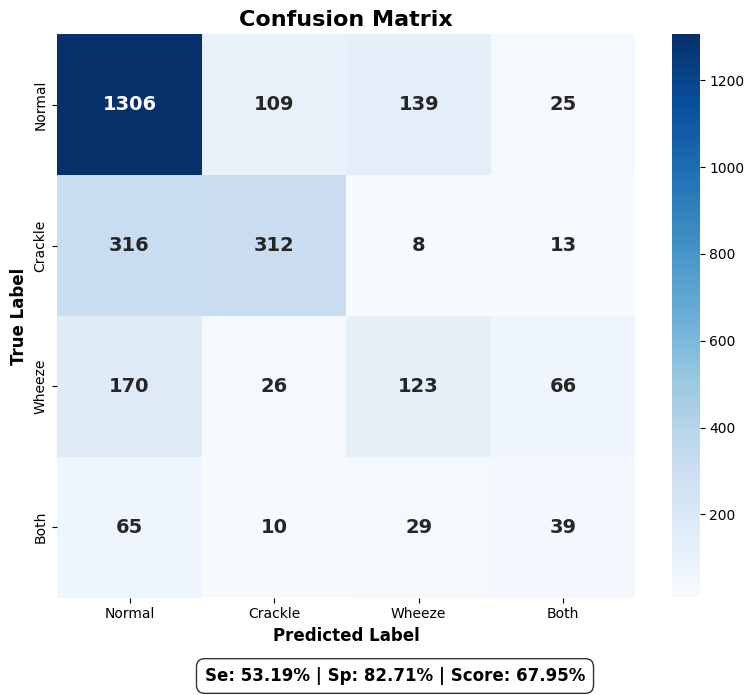

Matrice de confusion sauvegardée.


In [15]:
# Charger le meilleur modèle
CHECKPOINT_DIR = f"{DRIVE_DIR}/checkpoints"
gc.collect()
torch.cuda.empty_cache()
model = CustomAST(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best_model.pth"), map_location=DEVICE))
model.eval()

CLASSES = ['Normal', 'Crackle', 'Wheeze', 'Both']
all_preds, all_targets = [], []

with torch.no_grad():
    for inputs, labels, _ in test_loader:
        inputs = inputs.to(DEVICE)
        if DEVICE.type == 'cuda':
            with torch.amp.autocast('cuda'):
                preds = torch.argmax(model(inputs), dim=1)
        else:
            preds = torch.argmax(model(inputs), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

cm = confusion_matrix(all_targets, all_preds)
se = np.sum(cm[1:, 1:]) / np.sum(cm[1:, :])
sp = cm[0, 0] / np.sum(cm[0, :])
score = (se + sp) / 2

print(f"Sensitivity (Se): {se*100:.2f}%")
print(f"Specificity (Sp): {sp*100:.2f}%")
print(f"ICBHI Score:       {score*100:.2f}%")

# Matrice de confusion
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            annot_kws={"size": 14, "weight": "bold"})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
metrics_text = f"Se: {se*100:.2f}% | Sp: {sp*100:.2f}% | Score: {score*100:.2f}%"
plt.figtext(0.5, 0.02, metrics_text, ha='center', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.5'))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()
print("Matrice de confusion sauvegardée.")